In [1]:
import networkx as nx 
from sym_graphs.utils.utils import yaml_to_dotdict, group_by_dyn, compute_off_diag
from sym_graphs.correlators.k_correlators import Correlator
import matplotlib.pyplot as plt 
import itertools
import numpy as np

# Rook Graph 

In [2]:
Raw_Rook_edges =    [
                    ((0, 0), (1, 0)), ((0, 0), (2, 0)), ((0, 0), (3, 0)), ((0, 0), (0, 1)),
                    ((0, 0), (0, 2)), ((0, 0), (0, 3)), ((1, 0), (2, 0)), ((1, 0), (3, 0)),
                    ((1, 0), (1, 1)), ((1, 0), (1, 2)), ((1, 0), (1, 3)), ((2, 0), (3, 0)),
                    ((2, 0), (2, 1)), ((2, 0), (2, 2)), ((2, 0), (2, 3)), ((3, 0), (3, 1)),
                    ((3, 0), (3, 2)), ((3, 0), (3, 3)), ((0, 1), (0, 2)), ((0, 1), (0, 3)),
                    ((0, 1), (1, 1)), ((0, 1), (2, 1)), ((0, 1), (3, 1)), ((0, 2), (0, 3)),
                    ((0, 2), (1, 2)), ((0, 2), (2, 2)), ((0, 2), (3, 2)), ((0, 3), (1, 3)),
                    ((0, 3), (2, 3)), ((0, 3), (3, 3)), ((1, 1), (2, 1)), ((1, 1), (3, 1)),
                    ((1, 1), (1, 2)), ((1, 1), (1, 3)), ((2, 1), (3, 1)), ((2, 1), (2, 2)),
                    ((2, 1), (2, 3)), ((3, 1), (3, 2)), ((3, 1), (3, 3)), ((1, 2), (2, 2)),
                    ((1, 2), (3, 2)), ((1, 2), (1, 3)), ((2, 2), (3, 2)), ((2, 2), (2, 3)),
                    ((3, 2), (3, 3)), ((1, 3), (2, 3)), ((1, 3), (3, 3)), ((2, 3), (3, 3))
                    ]

Raw_Rook_generator =    [
                        [((0,2),(0,3)),((1,2),(1,3)),((2,2),(2,3)),((3,2),(3,3))],
                        [((0,1),(0,2)),((1,1),(1,2)),((2,1),(2,2)),((3,1),(3,2))],
                        [((2,0),(3,0)),((2,1),(3,1)),((2,2),(3,2)),((2,3),(3,3))],
                        [((1,0),(2,0)),((1,1),(2,1)),((1,2),(2,2)),((1,3),(2,3))],
                        [((1,0),(0,1)),((2,0),(0,2)),((3,0),(0,3)),((2,1),(1,2)),((3,1),(1,3)),((3,2),(2,3))],
                        [((0,0),(1,0)),((0,1),(1,1)),((0,2),(1,2)),((0,3),(1,3))]
                        ]

Nodes_lab = []
for edge in Raw_Rook_edges:
    Nodes_lab.append(edge[0])
    Nodes_lab.append(edge[1])
Rook_Nodes = {node : i for i, node in enumerate(list(set(Nodes_lab)))}
Rook_Edges= [(Rook_Nodes[u],Rook_Nodes[v]) for u,v in Raw_Rook_edges]

Rook_generator = []
for cycles in Raw_Rook_generator:
    Rook_cycle = []
    for cycle in cycles: 
        Rook_cycle.append([Rook_Nodes[u] for u in cycle])
    Rook_generator.append(Rook_cycle)

Rook = nx.Graph()
Rook.add_edges_from(Rook_Edges)

# Shrikhande Graph 

In [3]:

Shrikhande_edges =    [
                    (0, 1), (0, 2), (0, 6), (0, 7), (0, 9), (0, 15), (1, 2), (1, 3), (1, 7),
                    (1, 8), (1, 10), (2, 3), (2, 4), (2, 9), (2, 11), (3, 4), (3, 5), (3, 10),
                    (3, 12), (4, 5), (4, 6), (4, 11), (4, 13), (5, 6), (5, 7), (5, 12), (5, 14),
                    (6, 7), (6, 13), (6, 15), (7, 8), (7, 14), (8, 10), (8, 11), (8, 13), (8, 14),
                    (9, 11), (9, 12), (9, 14), (9, 15), (10, 12), (10, 13), (10, 15), (11, 13),
                    (11, 14), (12, 14), (12, 15), (13, 15) 
                    ]

Shrikhande_generator = [
                        [(2,7),(3,8),(4,14),(5,11),(6,9),(12,13)],
                        [(1,2),(4,10),(5,12),(6,15),(7,9),(8,11)],
                        [(0,1),(3,9),(4,11),(5,14),(6,8),(10,15)],
                        ]

Shrikhande = nx.Graph()
Shrikhande.add_edges_from(Shrikhande_edges)

# Emulation

In [ ]:
cfg_file = "../configs/emu_cfg/config_pair.yaml"
cfg = yaml_to_dotdict(cfg_file)

Corr_Rook = Correlator(Rook, cfg)
res_Rook = Corr_Rook.emulate_non_UD("SV",True)

Corr_Shrikhande = Correlator(Shrikhande, cfg)
res_Shrikhande = Corr_Shrikhande.emulate_non_UD("SV",True)

# 1st order

In [5]:
k = 2
C_Rook = Corr_Rook.k_body_full_chunked(res_Rook,k,chunk_s = 4096).cpu().numpy()
C_Shrikhande = Corr_Shrikhande.k_body_full_chunked(res_Shrikhande,k,chunk_s = 4096).cpu().numpy()

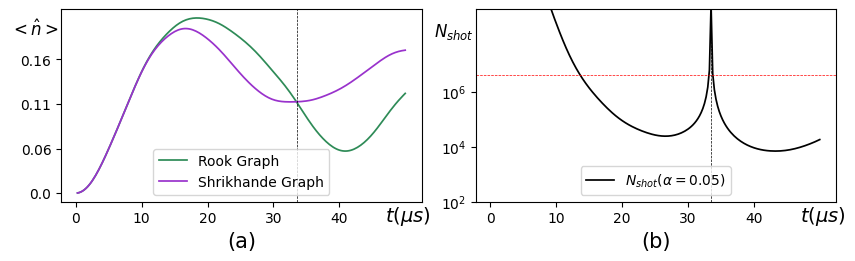

In [18]:
Basis =  list(itertools.product(range(len(Rook)), repeat= k ))
times = cfg.pulse.pulse_duration*np.array(list(res_Rook._times.values())[0])
plt.figure(figsize=(10,2.5))
plt.subplot(121)
#for elem in Basis[:-1]: 
#    plt.plot(times, C_Rook[:,*elem],"r",lw = 1.)
#    plt.plot(times, C_Shrikhande[:,*elem],"b",lw = 1.)
plt.plot(times, C_Rook[:,*Basis[-1]],"seagreen",lw = 1.25,label = 'Rook Graph')
plt.plot(times, C_Shrikhande[:,*Basis[-1]],"darkorchid",lw = 1.25,label = 'Shrikhande Graph')
plt.axvline(33500, ls = '--',c = 'k', lw = .5)

plt.legend(fontsize=10)
plt.xticks([10000*i for i in range(5)],[10*i for i in range(5)])
ymax = np.round(max([C_Shrikhande.max().item(),C_Rook.max().item()]),2)
step = ymax/4
plt.yticks([step*i for i in range(4)],[np.round(step*i,2) for i in range(4)])
plt.text(47000,- .035,"$t(\mu s)$",fontsize=14)
plt.text(-10000,.195,"$< \hat{n} >$",fontsize=12)
plt.xlabel('(a)',fontsize=15)


plt.subplot(122)
###################################################################################################
alpha = .05
prefact = 8*np.log(2*len(Rook)/alpha)
diags_rook = np.array([C_Rook[:,i,i] for i in range(16)])
diags_shrikhande = np.array([C_Shrikhande[:,i,i] for i in range(16)])
N_shots_diag = (prefact*(((diags_rook - diags_shrikhande).transpose())**-2)).mean(1)
############################### add off-diags #####################################################
off_diag_Rook = compute_off_diag(C_Rook,3)
off_diag_Shrikhande = compute_off_diag(C_Shrikhande,3)
diff = np.abs(off_diag_Rook[:, None, :] - off_diag_Shrikhande[None, :, :]).reshape(-1, off_diag_Rook.shape[1])
N_shots_off_diag =prefact/np.min((diff**2),axis = 0)
###################################################################################################
alpha = .05
plt.semilogy(times , N_shots_diag ,c = "k",label = "$N_{shot}(\\alpha = 0.05)$",lw = 1.25)
#plt.semilogy(times , N_shots_off_diag ,c = "grey",label = "$N_{off}(\\alpha = 0.05)$",lw = 1.25)

plt.axhline(4.2*10**6,ls = '--',c = 'r',lw = '.5')
plt.xticks([10000*i for i in range(5)],[10*i for i in range(5)])
plt.ylim(1e2, 1e9)

ticks, labels = plt.yticks()
idx = np.array([1, 2, 3, 4, 5])
ticks, labels = ticks[idx], [labels[i].get_text() for i in idx]
plt.yticks(ticks[:-2], labels[:-2])
plt.text(-8500,10**8,"$N_{shot}$",fontsize=12)
plt.text(47000, 20,"$t(\mu s)$",fontsize=14)
plt.xlabel('(b)',fontsize=15)
plt.legend(loc='lower center')

plt.axvline(33450, ls = '--',c = 'k', lw = .5)
save_path = "figures/rook_vs_shrikhande_omega_{:f}_delta_{:f}.pdf".format(cfg.pulse.Omega_max, cfg.pulse.delta)
plt.subplots_adjust(wspace=0.15)   # smaller = closer; default is ~0.2
plt.savefig(save_path, bbox_inches='tight', pad_inches=0)

In [7]:
diff = np.abs(off_diag_Rook[:, None, :] - off_diag_Shrikhande[None, :, :]).reshape(-1, off_diag_Rook.shape[1])

In [8]:
orbits_rook = {}
orbits_Shrikhande = {}
for k_ in range(1, 3):
    print(k_)
    C_Rook_ = Corr_Rook.k_body_full_chunked(res_Rook, k_, chunk_s=4096).cpu().numpy()
    C_Shrikhande_ = Corr_Shrikhande.k_body_full_chunked(res_Shrikhande, k_, chunk_s=4096).cpu().numpy()
    groups_rook = group_by_dyn(C_Rook_, 3)
    groups_Shrikhande = group_by_dyn(C_Shrikhande_, 3)
    orbits_rook[k_] = [len(v) for _,v in groups_rook.items()]
    orbits_Shrikhande[k_] =[len(v) for _,v in groups_Shrikhande.items()]

print(" Rook partitionning : ",orbits_rook)
print(" Shrikhande partitionning : ",orbits_Shrikhande)

1
2
 Rook partitionning :  {1: [16], 2: [16, 96, 144]}
 Shrikhande partitionning :  {1: [16], 2: [96, 16, 96, 48]}


# Check compatibility with orbits obtained from generators 

In [9]:
from sym_graphs.k_orbits.orbits_calculator import OrbitEngine 

O_rook = OrbitEngine(Rook, Rook_generator)
orbits_rook = O_rook.orbits_calculator(2)

O_shri = OrbitEngine(Shrikhande, Shrikhande_generator)
orbits_shri = O_shri.orbits_calculator(2)

print("Num orbits in the Rook graph for k = {:d} is : {:d}".format(k,len(orbits_rook)))
print("Num orbits in the Shrikhande graph  for k = {:d} is : {:d}".format(k,len(orbits_shri)))

Num orbits in the Rook graph for k = 2 is : 3
Num orbits in the Shrikhande graph  for k = 2 is : 4
